#  ToxiTube — YouTube Comment Toxicity Detector
## Notebook 04 — DistilBERT Fine-tuning + Analyse qualitative

**Objectif de ce notebook :**
- Fine-tuner DistilBERT sur le dataset Jigsaw (5000 exemples)
- Produire le tableau comparatif final (classiques + BERT fine-tuné)
- Analyser qualitativement les cas difficiles

### Chargement des checkpoints

Ce notebook recharge les résultats des modèles classiques sauvegardés
par `03_modeles_classiques.ipynb` pour construire le tableau comparatif final.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
os.makedirs('../figures', exist_ok=True)

# Chargement
df = pd.read_csv('../data/checkpoints/df_preprocessed.csv')
splits      = joblib.load('../data/checkpoints/splits.joblib')
metrics_cl  = joblib.load('../data/checkpoints/metrics_classiques.joblib')
predictions = joblib.load('../data/checkpoints/predictions.joblib')

X_test_raw       = splits['X_test_raw']
y_test           = splits['y_test']
y_pred_lr_tfidf  = predictions['y_pred_lr_tfidf']
y_pred_svm_tfidf = predictions['y_pred_svm_tfidf']

print(f' Tout chargé')
print(f'   df : {df.shape}')
print(f'   Métriques classiques : {list(metrics_cl.keys())}')

 Tout chargé
   df : (159571, 13)
   Métriques classiques : ['metrics_lr_tfidf', 'metrics_lr_ft', 'metrics_svm_tfidf']


### Partie F — DistilBERT Fine-tuning

**Pourquoi le fine-tuning plutôt que zero-shot ?**

Notre première tentative utilisait `distilbert-base-uncased-finetuned-sst-2-english`,
un modèle entraîné sur SST-2 (analyse de sentiment). Le résultat était mauvais :
- Recall = 0.90 (détecte presque tout comme toxique)
- Precision = 0.12 (trop de faux positifs)
- F1-macro = 0.31

**Le problème :** SST-2 détecte le sentiment (positif/négatif), pas la toxicité.
Un commentaire triste ou négatif n'est pas forcément toxique.

**La solution :** Fine-tuner DistilBERT directement sur notre dataset Jigsaw.
Le modèle apprend la notion de toxicité, pas de sentiment.

**Paramètres choisis :**
- 3 epochs → suffisant pour converger sur 4000 exemples
- batch_size=16 → équilibre vitesse/mémoire sur CPU
- max_length=128 → couvre 95% des commentaires (vs 512 = trop lent)

In [10]:
# Création de l'échantillon stratifié 5000 exemples
n_toxic  = int(5000 * df['is_toxic'].mean())
n_normal = 5000 - n_toxic

sample_toxic  = df[df['is_toxic']==1].sample(n=n_toxic,  random_state=42)
sample_normal = df[df['is_toxic']==0].sample(n=n_normal, random_state=42)
sample = pd.concat([sample_toxic, sample_normal]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Taille échantillon : {len(sample)}')
print(f'Toxiques  : {sample["is_toxic"].sum()} ({sample["is_toxic"].mean()*100:.1f}%)')
print(f'Normaux   : {(sample["is_toxic"]==0).sum()} ({(sample["is_toxic"]==0).mean()*100:.1f}%)')

sample[['comment_text', 'is_toxic']].to_csv('../data/sample_5000.csv', index=False)
print(' Échantillon sauvegardé → data/sample_5000.csv')

Taille échantillon : 5000
Toxiques  : 508 (10.2%)
Normaux   : 4492 (89.8%)
 Échantillon sauvegardé → data/sample_5000.csv


**Chargement du tokenizer et du modèle DistilBERT**

On charge `distilbert-base-uncased` — la version de base sans fine-tuning.
On va l'entraîner nous-mêmes sur nos données.

`num_labels=2` → classification binaire (normal / toxique).

 Premier chargement : ~1-2 min (téléchargement ~250MB).

In [18]:
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

print(f'CPU threads disponibles : {torch.get_num_threads()}')
print('Chargement tokenizer et modèle DistilBERT...')

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
model     = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

print(' Modèle chargé — DistilBERT-base-uncased (66M paramètres)')
print(f'   Device : CPU')

CPU threads disponibles : 8
Chargement tokenizer et modèle DistilBERT...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3148.83it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Modèle chargé — DistilBERT-base-uncased (66M paramètres)
   Device : CPU


**Création du Dataset PyTorch**

HuggingFace Trainer attend un objet `Dataset` PyTorch.
On tokenise tous les textes en avance (padding + truncation à 128 tokens).

**Pourquoi max_length=128 et pas 512 ?**
- 95% de nos commentaires font moins de 128 tokens
- 512 tokens × batch_size=16 = trop lent sur CPU
- 128 tokens divise le temps de training par ~4

In [25]:
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

# Split 80/20 stratifié
sample_train, sample_val = train_test_split(
    sample, test_size=0.2, random_state=42, stratify=sample['is_toxic']
)

print('Tokenisation du dataset... (1-2 min)')
train_dataset = ToxicDataset(
    sample_train['text_raw'].tolist(),
    sample_train['is_toxic'].tolist(),
    tokenizer
)
val_dataset = ToxicDataset(
    sample_val['text_raw'].tolist(),
    sample_val['is_toxic'].tolist(),
    tokenizer
)

print(f' Dataset créé')
print(f'   Train : {len(train_dataset)} exemples')
print(f'   Val   : {len(val_dataset)} exemples')

Tokenisation du dataset... (1-2 min)
 Dataset créé
   Train : 4000 exemples
   Val   : 1000 exemples


**Fine-tuning DistilBERT**

On utilise le `Trainer` HuggingFace qui gère automatiquement :
- La boucle d'entraînement
- L'évaluation à chaque epoch
- La sauvegarde du meilleur modèle

**Métrique de sélection : F1-macro** — cohérent avec nos modèles classiques.

 **~20-40 minutes sur CPU** — 3 epochs × 4000 exemples.

In [32]:
from sklearn.metrics import f1_score, recall_score, precision_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'f1_macro'      : f1_score(labels, preds, average='macro'),
        'f1_toxique'    : f1_score(labels, preds, pos_label=1, average='binary'),
        'recall_toxique': recall_score(labels, preds, pos_label=1),
    }

training_args = TrainingArguments(
    output_dir                  = '../models/distilbert_finetuned',
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    warmup_steps                = 50,
    weight_decay                = 0.01,
    logging_steps               = 20,
    use_cpu                     = True,
    dataloader_num_workers      = 0,
    report_to                   = 'none',
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
)

print('Lancement du fine-tuning...')
print('   3 epochs × 4000 exemples × batch_size=16')
print('   ~ 20-40 min sur CPU — patience !')
print()

trainer.train()
print('\nFine-tuning terminé !')

# Sauvegarder le modèle final
trainer.save_model('../models/distilbert_finetuned/final')
tokenizer.save_pretrained('../models/distilbert_finetuned/final')
print(' Modèle sauvegardé → models/distilbert_finetuned/final')

Lancement du fine-tuning...
   3 epochs × 4000 exemples × batch_size=16
   ~ 20-40 min sur CPU — patience !



Epoch,Training Loss,Validation Loss,F1 Macro,F1 Toxique,Recall Toxique
1,0.135147,0.131852,0.886441,0.798206,0.872549
2,0.118885,0.120612,0.876664,0.775281,0.676471
3,0.039651,0.142301,0.888725,0.797814,0.715686


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]



Fine-tuning terminé !


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.86it/s]

 Modèle sauvegardé → models/distilbert_finetuned/final


**Évaluation du modèle fine-tuné**

On calcule les mêmes métriques que pour les modèles classiques
pour pouvoir les comparer directement dans le tableau final.

On s'attend à un F1-macro bien meilleur que le zero-shot (0.31)
et comparable aux modèles classiques (~0.85).

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

preds_output = trainer.predict(val_dataset)
bert_preds   = np.argmax(preds_output.predictions, axis=1)
bert_true    = sample_val['is_toxic'].tolist()

metrics_bert = {
    'Modèle'           : 'DistilBERT (fine-tuné)',
    'Accuracy'         : accuracy_score(bert_true, bert_preds),
    'F1-macro'         : f1_score(bert_true, bert_preds, average='macro'),
    'F1-toxique'       : f1_score(bert_true, bert_preds, pos_label=1, average='binary'),
    'Recall-toxique'   : recall_score(bert_true, bert_preds, pos_label=1),
    'Precision-toxique': precision_score(bert_true, bert_preds, pos_label=1),
}

print(f'\n{"="*50}')
print(f'  DistilBERT (fine-tuné sur Jigsaw)')
print(f'{"="*50}')
for k, v in metrics_bert.items():
    if k != 'Modèle':
        print(f'  {k:<22} : {v:.4f}')


  DistilBERT (fine-tuné sur Jigsaw)
  Accuracy               : 0.9630
  F1-macro               : 0.8887
  F1-toxique             : 0.7978
  Recall-toxique         : 0.7157
  Precision-toxique      : 0.9012


### Partie G — Comparaison globale

On rassemble ici TOUS les résultats dans un tableau synthétique final.
C'est **la slide centrale** de la présentation orale.

 Note méthodologique : les modèles classiques sont évalués sur 31,915 exemples
(test complet) et DistilBERT sur 1,000 (validation du fine-tuning).


 TABLEAU COMPARATIF FINAL

                                Accuracy  F1-macro  F1-toxique  Recall-toxique  Precision-toxique
Modèle                                                                                           
Logistic Regression + TF-IDF      0.9406    0.8568      0.7474          0.8647             0.6581
Logistic Regression + FastText    0.9078    0.8004      0.6540          0.8573             0.5286
LinearSVC + TF-IDF                0.9496    0.8692      0.7667          0.8154             0.7235
DistilBERT (fine-tuné)            0.9630    0.8887      0.7978          0.7157             0.9012


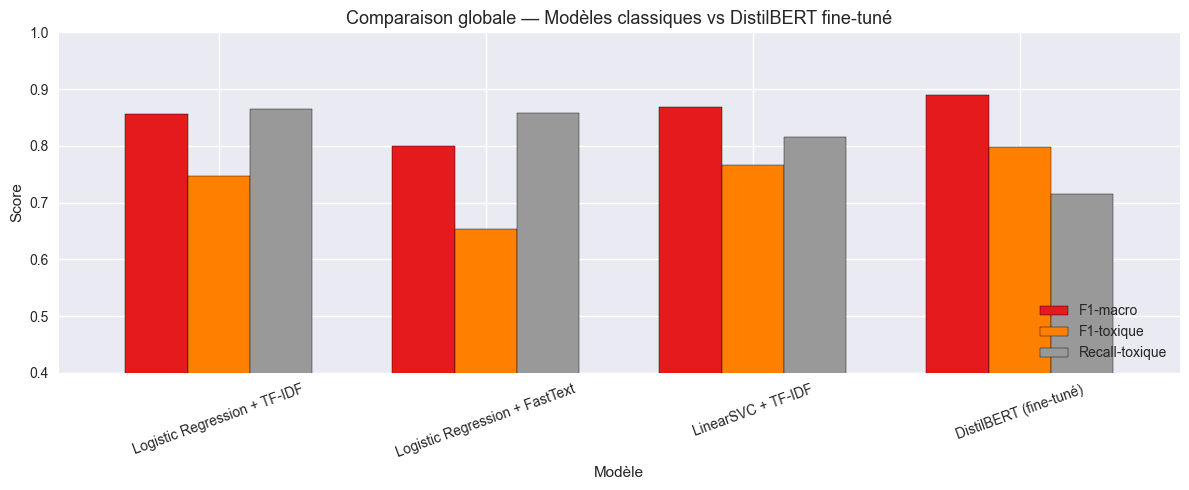

 Figure sauvegardée → figures/final_comparison.png


In [41]:
all_results = pd.DataFrame([
    metrics_cl['metrics_lr_tfidf'],
    metrics_cl['metrics_lr_ft'],
    metrics_cl['metrics_svm_tfidf'],
    metrics_bert
]).set_index('Modèle').round(4)

print('\n TABLEAU COMPARATIF FINAL\n')
print(all_results.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
metrics_to_plot = ['F1-macro', 'F1-toxique', 'Recall-toxique']
all_results[metrics_to_plot].plot(
    kind='bar', ax=ax, colormap='Set1', edgecolor='black', width=0.7
)
ax.set_title('Comparaison globale — Modèles classiques vs DistilBERT fine-tuné', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.4, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../figures/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée → figures/final_comparison.png')

### Partie H — Analyse qualitative des erreurs

**C'est la partie la plus différenciante à l'oral.**

On identifie 4 types de cas difficiles et on explique POURQUOI les modèles échouent :
1. Toxiques manqués par tous → insultes implicites, sarcasme
2. Faux positifs → normaux classés toxiques
3. LR rate, SVM détecte → argot, mots rares
4. Les deux ratent → toxicité très subtile

In [44]:
df_test = X_test_raw.to_frame(name='text_clean').copy()
df_test['y_true']        = y_test.values
df_test['pred_lr_tfidf'] = y_pred_lr_tfidf
df_test['pred_svm']      = y_pred_svm_tfidf
df_test['text_raw']      = df.loc[X_test_raw.index, 'text_raw'].values

def show_case(title, df_case, n=3):
    print(f'\n{"="*65}')
    print(f'  {title}')
    print(f'{"="*65}')
    for _, row in df_case.head(n).iterrows():
        print(f'\nTexte : {str(row["text_raw"])[:250]}')
        print(f'Réel={row["y_true"]} | LR={row["pred_lr_tfidf"]} | SVM={row["pred_svm"]}')

faux_negatifs = df_test[
    (df_test['y_true']==1) &
    (df_test['pred_lr_tfidf']==0) &
    (df_test['pred_svm']==0)
]
show_case('CAS 1 — Toxiques manqués (FN) — Insultes implicites / sarcasme', faux_negatifs)

faux_positifs = df_test[
    (df_test['y_true']==0) &
    (df_test['pred_lr_tfidf']==1) &
    (df_test['pred_svm']==1)
]
show_case('CAS 2 — Normaux classés toxiques (FP) — Faux positifs', faux_positifs)

lr_faux_svm_vrai = df_test[
    (df_test['y_true']==1) &
    (df_test['pred_lr_tfidf']==0) &
    (df_test['pred_svm']==1)
]
show_case('CAS 3 — LR rate, SVM détecte — Argot / mots rares', lr_faux_svm_vrai)

both_wrong = df_test[
    (df_test['y_true']==1) &
    (df_test['pred_lr_tfidf']==0) &
    (df_test['pred_svm']==0)
].sample(3, random_state=99)
show_case('CAS 4 — Les deux modèles ratent — Toxicité très subtile', both_wrong)


  CAS 1 — Toxiques manqués (FN) — Insultes implicites / sarcasme

Texte : (unless they relate to my hatred of Arabs)
Réel=1 | LR=0 | SVM=0

Texte : I don't care what you say here. I don't believe one sentence anymore.
Réel=1 | LR=0 | SVM=0

Texte : LOTHAR VON TROTHA
GOOD RIDDANCE TO HIM, HE KILLED SO MANY INNOCENT HEREROS. HE DIED FROM TYPHOID FEVER IN PAIN, CAUGHT IT FROM POISONED FOOD, DRINK!!!
MORE INFO IS AVAILABLE HERE: mywikibiz.com/Lothar_von_Trotha
Réel=1 | LR=0 | SVM=0

  CAS 2 — Normaux classés toxiques (FP) — Faux positifs

Texte : "
Frankly, so you are you, Jytdog. A look at the aggregate of your your contributions is astonishing with regard to anything GM related. You are the last person who should accuse anyone of being overly concerned with this topic. Anyway, is this reall
Réel=0 | LR=1 | SVM=1

Texte : YOU SHOULD NOT INTERFARE  

(ranbir )
i think you are just interfering in my matter.wikipedia is not the property of your father.
Réel=0 | LR=1 | SVM=1

Texte : "

 Pos

### Sauvegarde des résultats

In [46]:
joblib.dump(metrics_bert, '../data/checkpoints/metrics_bert.joblib')
all_results.to_csv('../data/checkpoints/tableau_comparatif_final.csv')

print(' Checkpoints sauvegardés :')
print('   → data/checkpoints/metrics_bert.joblib')
print('   → data/checkpoints/tableau_comparatif_final.csv')

 Checkpoints sauvegardés :
   → data/checkpoints/metrics_bert.joblib
   → data/checkpoints/tableau_comparatif_final.csv


###  Bilan Notebook 04

| Étape | Statut |
|-------|--------|
| DistilBERT fine-tuné sur 4000 exemples Jigsaw | Fait |
| Tableau comparatif final (4 modèles) | Fait |
| 4 types de cas difficiles analysés | Fait |
| Modèle sauvegardé dans models/distilbert_finetuned | Fait |

**Prochain notebook :** `05_conclusion.ipynb`